In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('../../data/data/processed/fdemand.csv')

In [3]:
data_no3000 = data[data['end_station'] != 3000]

In [4]:
data_no3000.head()

,duration,start_station,end_station,plan_duration,st_year,st_month,st_day,st_hour,st_minute,end_year,...,end_name,end_lat,end_lon,dist_km,avg_wind,precip,snow,snow_ground,max_temp,min_temp
0,11,3049,3072,30,2020,1,1,0,13,2020,...,Front & Carpenter,39.93445,-75.14541,1.208846,9.17,0.0,0.0,0.0,42,29
1,28,3124,3053,30,2020,1,1,0,14,2020,...,Point Breeze & Tasker,39.93231,-75.18154,4.295275,9.17,0.0,0.0,0.0,42,29
2,28,3124,3053,30,2020,1,1,0,14,2020,...,Point Breeze & Tasker,39.93231,-75.18154,4.295275,9.17,0.0,0.0,0.0,42,29
3,21,3005,3018,30,2020,1,1,0,17,2020,...,12th & Filbert,39.95273,-75.15979,1.471505,9.17,0.0,0.0,0.0,42,29
4,21,3005,3018,30,2020,1,1,0,17,2020,...,12th & Filbert,39.95273,-75.15979,1.471505,9.17,0.0,0.0,0.0,42,29


making the data set

In [5]:
# Define all_station_coords_df_full
# Extract unique station coordinates from the main data
# We'll combine start and end station information to get a comprehensive list.

# Collect start station info (without 'start_name' as it's missing)
start_stations = data[['start_station', 'st_lat', 'st_lon']].drop_duplicates().copy()
start_stations.rename(columns={'start_station': 'station_id',
                               'st_lat': 'latitude',
                               'st_lon': 'longitude'}, inplace=True)
# Add a placeholder for station_name for start_stations
start_stations['station_name'] = None

# Collect end station info (with 'end_name')
end_stations = data[['end_station', 'end_lat', 'end_lon', 'end_name']].drop_duplicates().copy()
end_stations.rename(columns={'end_station': 'station_id',
                             'end_lat': 'latitude',
                             'end_lon': 'longitude',
                             'end_name': 'station_name'}, inplace=True)

# Combine and remove duplicates to get all unique station coordinates and names
# Use a common set of columns for concat to ensure they align
all_station_coords_df_full = pd.concat([start_stations[['station_id', 'latitude', 'longitude', 'station_name']],
                                        end_stations[['station_id', 'latitude', 'longitude', 'station_name']]]) \
                            .drop_duplicates(subset=['station_id']).reset_index(drop=True)

# Ensure station_id is integer type for consistent merging
all_station_coords_df_full['station_id'] = all_station_coords_df_full['station_id'].astype(int)


# Preprocessing: Calculate daily net change per station from data_no3000
# Ensure 'st_year', 'st_month', 'st_day' are used to create a date column
# This assumes data_no3000 contains 'start_station', 'end_station', 'st_year', 'st_month', 'st_day'

# Create a daily identifier
# Make a copy to avoid SettingWithCopyWarning
data_for_net_change = data_no3000.copy()
data_for_net_change['date'] = pd.to_datetime({'year': data_for_net_change['st_year'], 'month': data_for_net_change['st_month'], 'day': data_for_net_change['st_day']})

# Count bikes leaving each station per day
departures = data_for_net_change.groupby(['date', 'start_station']).size().reset_index(name='departures')
departures.rename(columns={'start_station': 'station_id'}, inplace=True)

# Count bikes arriving at each station per day
arrivals = data_for_net_change.groupby(['date', 'end_station']).size().reset_index(name='arrivals')
arrivals.rename(columns={'end_station': 'station_id'}, inplace=True)

# Merge departures and arrivals
daily_station_activity = pd.merge(departures, arrivals, on=['date', 'station_id'], how='outer').fillna(0)

# Calculate net change
daily_station_activity['net_change'] = daily_station_activity['arrivals'] - daily_station_activity['departures']

In [6]:
# 1. Create a directed graph representing the bike-sharing network
G = nx.DiGraph()

# Add all unique stations as nodes
all_unique_stations = pd.concat([data_no3000['start_station'], data_no3000['end_station']]).unique()
G.add_nodes_from(all_unique_stations)

# Add edges with weights (number of trips) between start and end stations
trip_counts = data_no3000.groupby(['start_station', 'end_station']).size().reset_index(name='trip_count')

for _, row in trip_counts.iterrows():
    G.add_edge(row['start_station'], row['end_station'], weight=row['trip_count'])

In [7]:
# 2. Calculate Centrality Measures
centrality_measures = {
    'station_id': [],
    'degree_centrality_in': [],
    'degree_centrality_out': [],
    'betweenness_centrality_unweighted': [],
    'closeness_centrality_unweighted': [],
    'eigenvector_centrality_weighted': []
}

in_degree_centrality = nx.in_degree_centrality(G)
out_degree_centrality = nx.out_degree_centrality(G)

# Use unweighted centrality for betweenness and closeness for a standard interpretation of 'paths'
betweenness_unweighted = nx.betweenness_centrality(G)
closeness_unweighted = nx.closeness_centrality(G)





In [8]:
# Use weighted eigenvector centrality, where higher trip count means more influence
try:
    eigenvector_weighted = nx.eigenvector_centrality(G, weight='weight', max_iter=1000, tol=1e-06)
except nx.PowerIterationFailedConvergence:
    print("Eigenvector centrality did not converge for some nodes. Assigning 0 to non-converged nodes.")
    eigenvector_weighted = {node: 0 for node in G.nodes()}
except Exception as e:
    print(f"Error calculating eigenvector centrality: {e}. Assigning 0 to all nodes.")
    eigenvector_weighted = {node: 0 for node in G.nodes()}

In [9]:
for station_id in G.nodes():
    centrality_measures['station_id'].append(station_id)
    centrality_measures['degree_centrality_in'].append(in_degree_centrality.get(station_id, 0))
    centrality_measures['degree_centrality_out'].append(out_degree_centrality.get(station_id, 0))
    centrality_measures['betweenness_centrality_unweighted'].append(betweenness_unweighted.get(station_id, 0))
    centrality_measures['closeness_centrality_unweighted'].append(closeness_unweighted.get(station_id, 0))
    centrality_measures['eigenvector_centrality_weighted'].append(eigenvector_weighted.get(station_id, 0))

station_centrality_df = pd.DataFrame(centrality_measures)

In [10]:
# 3. Prepare base DataFrame for modeling: `daily_station_activity`
# This DataFrame contains 'date', 'station_id', 'departures', 'arrivals', 'net_change'
modeling_df = daily_station_activity.copy()

In [11]:
# 4. Add Time-based Features
modeling_df['weekday'] = modeling_df['date'].dt.weekday # Monday=0, Sunday=6
modeling_df['dayofyear'] = modeling_df['date'].dt.dayofyear
modeling_df['month'] = modeling_df['date'].dt.month
modeling_df['is_weekend'] = modeling_df['date'].dt.weekday.isin([5, 6])

In [12]:
# 5. Aggregate Daily Weather Data
# Create a 'date' column in data_no3000 to merge with modeling_df
weather_data_temp = data_no3000.copy()
weather_data_temp['date'] = pd.to_datetime({'year': weather_data_temp['st_year'], 'month': weather_data_temp['st_month'], 'day': weather_data_temp['st_day']})

weather_features = weather_data_temp.groupby('date')[['avg_wind', 'precip', 'snow', 'snow_ground', 'max_temp', 'min_temp']].mean().reset_index()

In [13]:
# 6. Merge all features into the modeling_df
# Merge centrality measures
modeling_df = pd.merge(modeling_df, station_centrality_df, on='station_id', how='left')

# Merge weather features
modeling_df = pd.merge(modeling_df, weather_features, on='date', how='left')

# Handle potential NaNs after merging
# Fill centrality NaNs with 0 (e.g., if a station existed in daily_station_activity but not in the graph)
centrality_cols = [col for col in station_centrality_df.columns if col != 'station_id']
for col in centrality_cols:
    modeling_df[col] = modeling_df[col].fillna(0)

# Fill weather NaNs, assuming weather features are generally available. Forward fill, then fill remaining with 0 or mean.
modeling_df.sort_values(by=['date', 'station_id'], inplace=True)
modeling_df[weather_features.columns.drop('date')] = modeling_df[weather_features.columns.drop('date')].ffill()
# Fill any remaining NaNs at the beginning of the series or if ffill couldn't propagate
modeling_df[weather_features.columns.drop('date')] = modeling_df[weather_features.columns.drop('date')].fillna(0)

In [14]:
# Display the head and info of the prepared dataset
print("Prepared dataset for XGBoost model (first 5 rows):")
display(modeling_df.head())

Prepared dataset for XGBoost model (first 5 rows):


,date,station_id,departures,arrivals,net_change,weekday,dayofyear,month,is_weekend,degree_centrality_in,degree_centrality_out,betweenness_centrality_unweighted,closeness_centrality_unweighted,eigenvector_centrality_weighted,avg_wind,precip,snow,snow_ground,max_temp,min_temp
0,2020-01-01,3004,2.0,2.0,0.0,2,1,1,False,0.610465,0.607558,0.000245,0.714643,0.022472,9.17,0.0,0.0,0.0,42.0,29.0
1,2020-01-01,3005,10.0,2.0,-8.0,2,1,1,False,0.834302,0.834302,0.001171,0.853601,0.051949,9.17,0.0,0.0,0.0,42.0,29.0
2,2020-01-01,3006,3.0,4.0,1.0,2,1,1,False,0.857558,0.845930,0.002645,0.871201,0.066821,9.17,0.0,0.0,0.0,42.0,29.0
3,2020-01-01,3007,3.0,7.0,4.0,2,1,1,False,0.886628,0.895349,0.002138,0.894249,0.172888,9.17,0.0,0.0,0.0,42.0,29.0
4,2020-01-01,3008,1.0,1.0,0.0,2,1,1,False,0.694767,0.764535,0.001102,0.761320,0.010123,9.17,0.0,0.0,0.0,42.0,29.0


In [15]:
print("\nInformation about the prepared dataset:")
modeling_df.info()


Information about the prepared dataset:
<class 'pandas.DataFrame'>
RangeIndex: 449633 entries, 0 to 449632
Data columns (total 20 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   date                               449633 non-null  datetime64[us]
 1   station_id                         449633 non-null  int64         
 2   departures                         449633 non-null  float64       
 3   arrivals                           449633 non-null  float64       
 4   net_change                         449633 non-null  float64       
 5   weekday                            449633 non-null  int32         
 6   dayofyear                          449633 non-null  int32         
 7   month                              449633 non-null  int32         
 8   is_weekend                         449633 non-null  bool          
 9   degree_centrality_in               449633 non-null  float64   

### XGBoost Model for Predicting Whole Number of Arrivals with Rounding

In [16]:
# Define target for Arrivals model
target_arrivals = modeling_df['arrivals']

# Features for Arrivals model (exclude arrivals and departures and net_change)
features_arrivals = modeling_df.drop(columns=['date', 'departures', 'arrivals', 'net_change', 'station_id'])
features_arrivals['is_weekend'] = features_arrivals['is_weekend'].astype(int)

In [17]:
# Split data for Arrivals model using time series approach

# Define the split dates
train_end_date = '2024-12-31'
test_start_date = '2025-01-01'

# Create a copy of modeling_df to work with, ensuring 'date' is a datetime object
modeling_df_copy = modeling_df.copy()
modeling_df_copy['date'] = pd.to_datetime(modeling_df_copy['date'])

In [18]:
# Filter data for training and testing periods
train_df = modeling_df_copy[modeling_df_copy['date'] <= train_end_date]
test_df = modeling_df_copy[modeling_df_copy['date'] >= test_start_date]

# Ensure features_arrivals and target_arrivals are defined from the full modeling_df for column consistency
# Features for Arrivals model (exclude arrivals and departures and net_change, and date/station_id)
feature_cols = modeling_df_copy.drop(columns=['date', 'departures', 'arrivals', 'net_change', 'station_id']).columns

In [19]:
X_train_arrivals = train_df[feature_cols]
y_train_arrivals = train_df['arrivals']

X_test_arrivals = test_df[feature_cols]
y_test_arrivals = test_df['arrivals']

In [20]:
# Convert 'is_weekend' to int if it's not already (as done previously)
X_train_arrivals['is_weekend'] = X_train_arrivals['is_weekend'].astype(int)
X_test_arrivals['is_weekend'] = X_test_arrivals['is_weekend'].astype(int)

print("X_train_arrivals shape:", X_train_arrivals.shape)
print("X_test_arrivals shape:", X_test_arrivals.shape)
print("y_train_arrivals shape:", y_train_arrivals.shape)
print("y_test_arrivals shape:", y_test_arrivals.shape)

print(f"Training period: {train_df['date'].min().strftime('%Y-%m-%d')} to {train_df['date'].max().strftime('%Y-%m-%d')}")
print(f"Testing period: {test_df['date'].min().strftime('%Y-%m-%d')} to {test_df['date'].max().strftime('%Y-%m-%d')}")

X_train_arrivals shape: (332307, 15)
X_test_arrivals shape: (117326, 15)
y_train_arrivals shape: (332307,)
y_test_arrivals shape: (117326,)
Training period: 2020-01-01 to 2024-12-31
Testing period: 2025-01-01 to 2026-03-31


In [21]:
# Initialize and train the XGBoost Regressor for Arrivals
xgb_arrivals_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

print("\nTraining XGBoost model for Arrivals...")
xgb_arrivals_model.fit(X_train_arrivals, y_train_arrivals)
print("XGBoost model for Arrivals training complete.")


Training XGBoost model for Arrivals...
XGBoost model for Arrivals training complete.


In [22]:
# Make predictions and round to nearest whole number (and ensure non-negative)
# 1. Normal predictions (raw output from the model)
y_pred_arrivals_normal = xgb_arrivals_model.predict(X_test_arrivals)

# 2. Standard Round predictions
y_pred_arrivals_standard_rounded = np.round(y_pred_arrivals_normal)
y_pred_arrivals_standard_rounded[y_pred_arrivals_standard_rounded < 0] = 0 # Ensure no negative predictions for counts

# 3. Floor Round predictions
y_pred_arrivals_floor_rounded = np.floor(y_pred_arrivals_normal)
y_pred_arrivals_floor_rounded[y_pred_arrivals_floor_rounded < 0] = 0 # Ensure no negative predictions for counts

# 4. Ceiling Round predictions
y_pred_arrivals_ceil_rounded = np.ceil(y_pred_arrivals_normal)
y_pred_arrivals_ceil_rounded[y_pred_arrivals_ceil_rounded < 0] = 0 # Ensure no negative predictions for counts

In [23]:
# Evaluate the Arrivals model

# 1. Normal Predictions
mae_arrivals_normal = mean_absolute_error(y_test_arrivals, y_pred_arrivals_normal)
r2_arrivals_normal = r2_score(y_test_arrivals, y_pred_arrivals_normal)

print("\n--- XGBoost Model Performance (Arrivals - Normal Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_arrivals_normal:.3f}")
print(f"R-squared (R2): {r2_arrivals_normal:.3f}")

# 2. Standard Rounded Predictions
mae_arrivals_standard_rounded = mean_absolute_error(y_test_arrivals, y_pred_arrivals_standard_rounded)
r2_arrivals_standard_rounded = r2_score(y_test_arrivals, y_pred_arrivals_standard_rounded)

print("\n--- XGBoost Model Performance (Arrivals - Standard Rounded Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_arrivals_standard_rounded:.3f}")
print(f"R-squared (R2): {r2_arrivals_standard_rounded:.3f}")

# 3. Floor Rounded Predictions
mae_arrivals_floor_rounded = mean_absolute_error(y_test_arrivals, y_pred_arrivals_floor_rounded)
r2_arrivals_floor_rounded = r2_score(y_test_arrivals, y_pred_arrivals_floor_rounded)

print("\n--- XGBoost Model Performance (Arrivals - Floor Rounded Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_arrivals_floor_rounded:.3f}")
print(f"R-squared (R2): {r2_arrivals_floor_rounded:.3f}")

# 4. Ceiling Rounded Predictions
mae_arrivals_ceil_rounded = mean_absolute_error(y_test_arrivals, y_pred_arrivals_ceil_rounded)
r2_arrivals_ceil_rounded = r2_score(y_test_arrivals, y_pred_arrivals_ceil_rounded)

print("\n--- XGBoost Model Performance (Arrivals - Ceiling Rounded Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_arrivals_ceil_rounded:.3f}")
print(f"R-squared (R2): {r2_arrivals_ceil_rounded:.3f}")


--- XGBoost Model Performance (Arrivals - Normal Predictions) ---
Mean Absolute Error (MAE): 4.634
R-squared (R2): 0.679

--- XGBoost Model Performance (Arrivals - Standard Rounded Predictions) ---
Mean Absolute Error (MAE): 4.623
R-squared (R2): 0.679

--- XGBoost Model Performance (Arrivals - Floor Rounded Predictions) ---
Mean Absolute Error (MAE): 4.762
R-squared (R2): 0.663

--- XGBoost Model Performance (Arrivals - Ceiling Rounded Predictions) ---
Mean Absolute Error (MAE): 4.540
R-squared (R2): 0.692


In [24]:
# Display some predictions vs actual
predictions_comparison_arrivals = pd.DataFrame({
    'Actual Arrivals': y_test_arrivals,
    'Predicted Arrivals (Normal)': y_pred_arrivals_normal,
    'Predicted Arrivals (Standard Rounded)': y_pred_arrivals_standard_rounded,
    'Predicted Arrivals (Floor Rounded)': y_pred_arrivals_floor_rounded,
    'Predicted Arrivals (Ceiling Rounded)': y_pred_arrivals_ceil_rounded
})
display(predictions_comparison_arrivals.head())

,Actual Arrivals,Predicted Arrivals (Normal),Predicted Arrivals (Standard Rounded),Predicted Arrivals (Floor Rounded),Predicted Arrivals (Ceiling Rounded)
332307,8.0,5.770600,6.0,5.0,6.0
332308,3.0,7.580323,8.0,7.0,8.0
332309,17.0,20.751146,21.0,20.0,21.0
332310,0.0,3.122774,3.0,3.0,4.0
332311,7.0,11.345425,11.0,11.0,12.0


### XGBoost Model for Predicting Whole Number of Departures with Rounding

In [25]:
# Define target for Departures model
target_departures = modeling_df['departures']

# Features for Departures model (exclude arrivals and departures and net_change)
features_departures = modeling_df.drop(columns=['date', 'departures', 'arrivals', 'net_change', 'station_id'])
features_departures['is_weekend'] = features_departures['is_weekend'].astype(int)

In [26]:
# Split data for Departures model using time series approach

X_train_departures = train_df[feature_cols]
y_train_departures = train_df['departures']

X_test_departures = test_df[feature_cols]
y_test_departures = test_df['departures']

# Convert 'is_weekend' to int if it's not already
X_train_departures['is_weekend'] = X_train_departures['is_weekend'].astype(int)
X_test_departures['is_weekend'] = X_test_departures['is_weekend'].astype(int)

print("X_train_departures shape:", X_train_departures.shape)
print("X_test_departures shape:", X_test_departures.shape)
print("y_train_departures shape:", y_train_departures.shape)
print("y_test_departures shape:", y_test_departures.shape)

X_train_departures shape: (332307, 15)
X_test_departures shape: (117326, 15)
y_train_departures shape: (332307,)
y_test_departures shape: (117326,)


In [27]:
# Initialize and train the XGBoost Regressor for Departures
xgb_departures_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

print("\nTraining XGBoost model for Departures...")
xgb_departures_model.fit(X_train_departures, y_train_departures)
print("XGBoost model for Departures training complete.")


Training XGBoost model for Departures...
XGBoost model for Departures training complete.


In [28]:
# Make predictions and round to nearest whole number (and ensure non-negative)
# 1. Normal predictions (raw output from the model)
y_pred_departures_normal = xgb_departures_model.predict(X_test_departures)

# 2. Standard Round predictions
y_pred_departures_standard_rounded = np.round(y_pred_departures_normal)
y_pred_departures_standard_rounded[y_pred_departures_standard_rounded < 0] = 0 # Ensure no negative predictions for counts

# 3. Floor Round predictions
y_pred_departures_floor_rounded = np.floor(y_pred_departures_normal)
y_pred_departures_floor_rounded[y_pred_departures_floor_rounded < 0] = 0 # Ensure no negative predictions for counts

# 4. Ceiling Round predictions
y_pred_departures_ceil_rounded = np.ceil(y_pred_departures_normal)
y_pred_departures_ceil_rounded[y_pred_departures_ceil_rounded < 0] = 0 # Ensure no negative predictions for counts

In [29]:
# Evaluate the Departures model

# 1. Normal Predictions
mae_departures_normal = mean_absolute_error(y_test_departures, y_pred_departures_normal)
r2_departures_normal = r2_score(y_test_departures, y_pred_departures_normal)

print("\n--- XGBoost Model Performance (Departures - Normal Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_departures_normal:.3f}")
print(f"R-squared (R2): {r2_departures_normal:.3f}")

# 2. Standard Rounded Predictions
mae_departures_standard_rounded = mean_absolute_error(y_test_departures, y_pred_departures_standard_rounded)
r2_departures_standard_rounded = r2_score(y_test_departures, y_pred_departures_standard_rounded)

print("\n--- XGBoost Model Performance (Departures - Standard Rounded Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_departures_standard_rounded:.3f}")
print(f"R-squared (R2): {r2_departures_standard_rounded:.3f}")

# 3. Floor Rounded Predictions
mae_departures_floor_rounded = mean_absolute_error(y_test_departures, y_pred_departures_floor_rounded)
r2_departures_floor_rounded = r2_score(y_test_departures, y_pred_departures_floor_rounded)

print("\n--- XGBoost Model Performance (Departures - Floor Rounded Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_departures_floor_rounded:.3f}")
print(f"R-squared (R2): {r2_departures_floor_rounded:.3f}")

# 4. Ceiling Rounded Predictions
mae_departures_ceil_rounded = mean_absolute_error(y_test_departures, y_pred_departures_ceil_rounded)
r2_departures_ceil_rounded = r2_score(y_test_departures, y_pred_departures_ceil_rounded)

print("\n--- XGBoost Model Performance (Departures - Ceiling Rounded Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_departures_ceil_rounded:.3f}")
print(f"R-squared (R2): {r2_departures_ceil_rounded:.3f}")


--- XGBoost Model Performance (Departures - Normal Predictions) ---
Mean Absolute Error (MAE): 4.612
R-squared (R2): 0.685

--- XGBoost Model Performance (Departures - Standard Rounded Predictions) ---
Mean Absolute Error (MAE): 4.599
R-squared (R2): 0.684

--- XGBoost Model Performance (Departures - Floor Rounded Predictions) ---
Mean Absolute Error (MAE): 4.738
R-squared (R2): 0.668

--- XGBoost Model Performance (Departures - Ceiling Rounded Predictions) ---
Mean Absolute Error (MAE): 4.513
R-squared (R2): 0.697


In [30]:
# Display some predictions vs actual
predictions_comparison_departures = pd.DataFrame({
    'Actual Departures': y_test_departures,
    'Predicted Departures (Normal)': y_pred_departures_normal,
    'Predicted Departures (Standard Rounded)': y_pred_departures_standard_rounded,
    'Predicted Departures (Floor Rounded)': y_pred_departures_floor_rounded,
    'Predicted Departures (Ceiling Rounded)': y_pred_departures_ceil_rounded
})
display(predictions_comparison_departures.head())

,Actual Departures,Predicted Departures (Normal),Predicted Departures (Standard Rounded),Predicted Departures (Floor Rounded),Predicted Departures (Ceiling Rounded)
332307,14.0,5.082113,5.0,5.0,6.0
332308,3.0,8.217517,8.0,8.0,9.0
332309,16.0,18.782948,19.0,18.0,19.0
332310,3.0,2.988738,3.0,2.0,3.0
332311,4.0,13.063259,13.0,13.0,14.0


### XGBoost Feature Importance

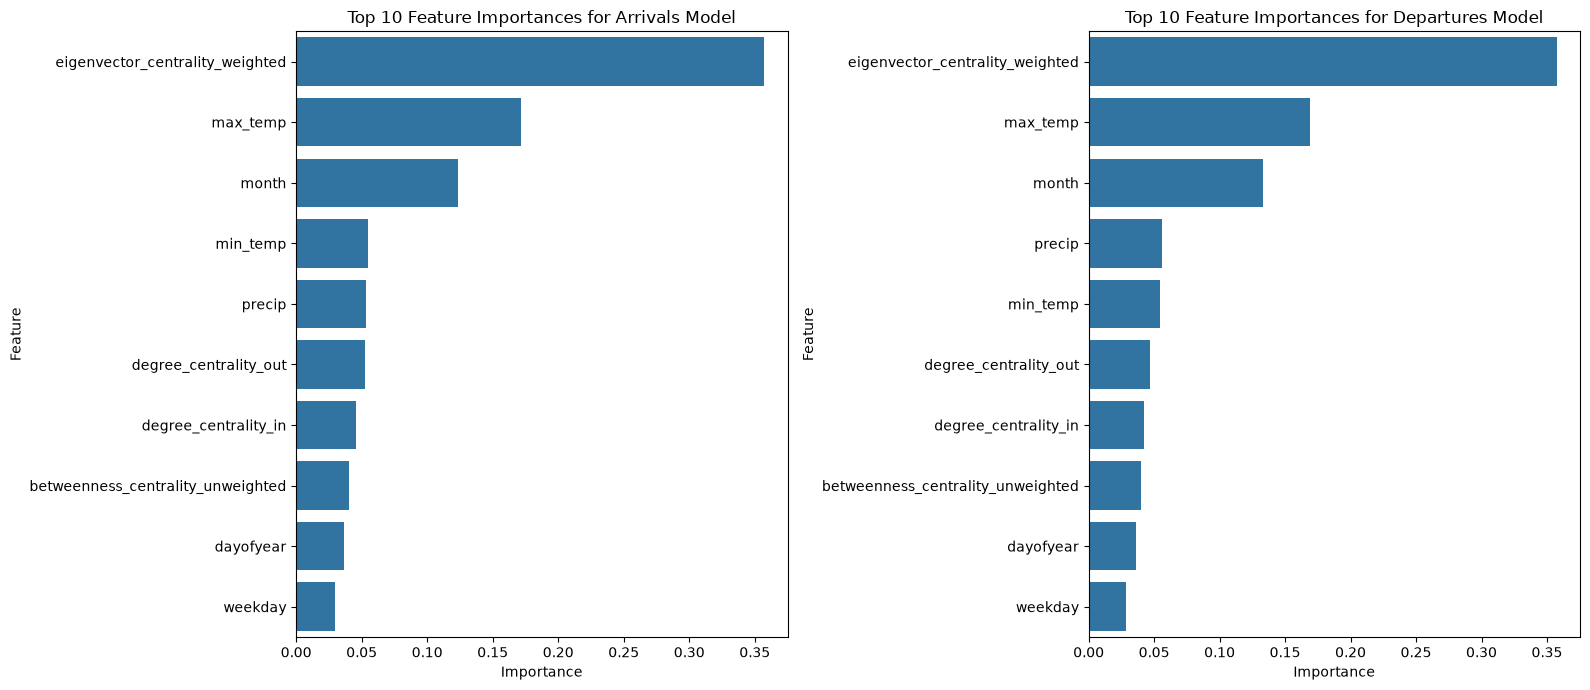

In [31]:
plt.figure(figsize=(16, 7))

# --- Feature Importance for Arrivals Model ---
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
feature_importances_arrivals = pd.DataFrame({
    'feature': X_train_arrivals.columns,
    'importance': xgb_arrivals_model.feature_importances_
}).sort_values(by='importance', ascending=False)
sns.barplot(x='importance', y='feature', data=feature_importances_arrivals.head(10))
plt.title('Top 10 Feature Importances for Arrivals Model')
plt.xlabel('Importance')
plt.ylabel('Feature')

# --- Feature Importance for Departures Model ---
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
feature_importances_departures = pd.DataFrame({
    'feature': X_train_departures.columns,
    'importance': xgb_departures_model.feature_importances_
}).sort_values(by='importance', ascending=False)
sns.barplot(x='importance', y='feature', data=feature_importances_departures.head(10))
plt.title('Top 10 Feature Importances for Departures Model')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()


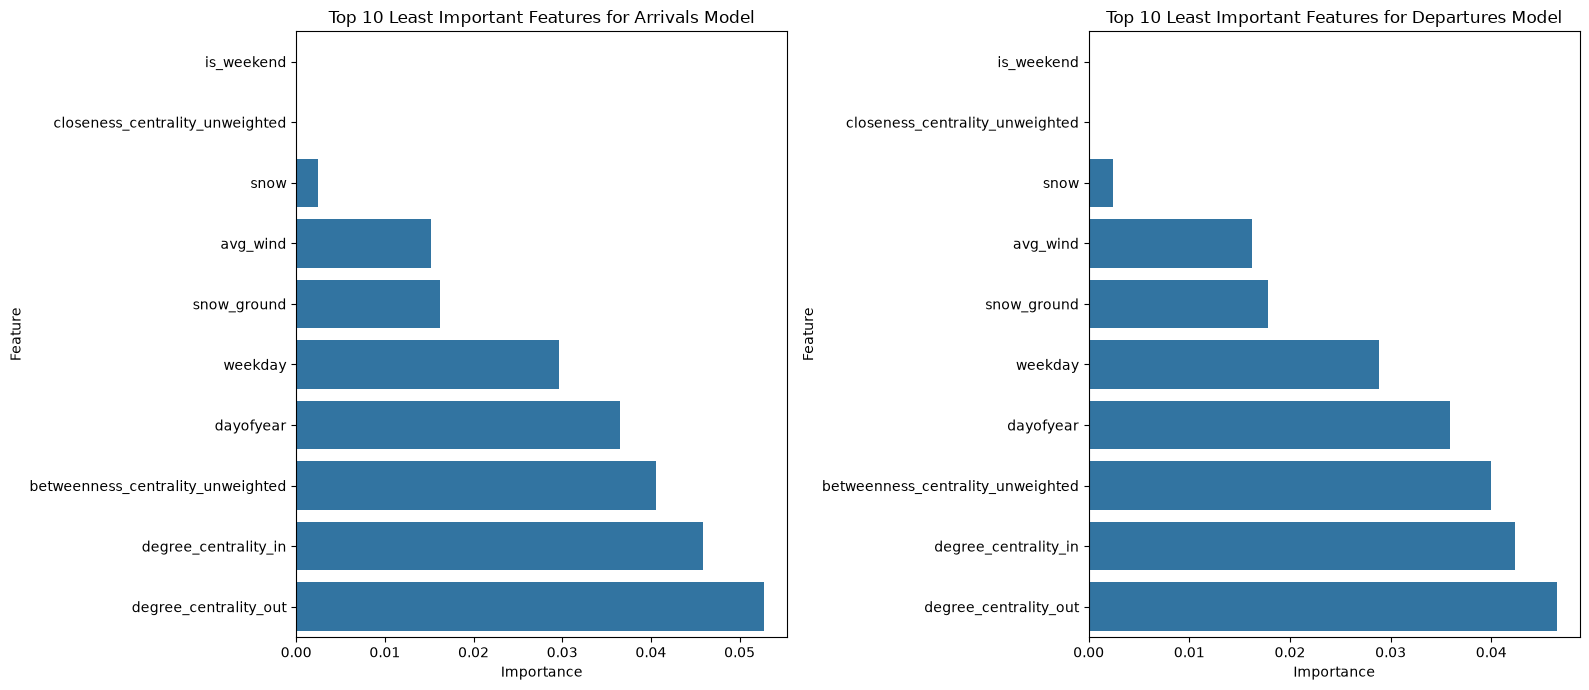

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 7))

# --- Feature Importance for Arrivals Model (Least Important) ---
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
feature_importances_arrivals_least = pd.DataFrame({
    'feature': X_train_arrivals.columns,
    'importance': xgb_arrivals_model.feature_importances_
}).sort_values(by='importance', ascending=True)
sns.barplot(x='importance', y='feature', data=feature_importances_arrivals_least.head(10))
plt.title('Top 10 Least Important Features for Arrivals Model')
plt.xlabel('Importance')
plt.ylabel('Feature')

# --- Feature Importance for Departures Model (Least Important) ---
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
feature_importances_departures_least = pd.DataFrame({
    'feature': X_train_departures.columns,
    'importance': xgb_departures_model.feature_importances_
}).sort_values(by='importance', ascending=True)
sns.barplot(x='importance', y='feature', data=feature_importances_departures_least.head(10))
plt.title('Top 10 Least Important Features for Departures Model')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [33]:
print(f"Number of features for Arrivals model: {X_train_arrivals.shape[1]}")
print(f"Number of features for Departures model: {X_train_departures.shape[1]}")

Number of features for Arrivals model: 15
Number of features for Departures model: 15


## Model Tuning: Hyperparameter Optimization with GridSearchCV

Hyperparameter tuning is crucial for getting the best performance out of your machine learning models. We'll use `GridSearchCV` to search for optimal `n_estimators`, `max_depth`, and `learning_rate` for the XGBoost Arrivals model.

In [34]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of boosting rounds
    'max_depth': [3, 5, 7],         # Maximum depth of a tree
    'learning_rate': [0.01, 0.1, 0.2] # Step size shrinkage to prevent overfitting
}

# Initialize the XGBoost Regressor for Arrivals
# We use the same random_state for reproducibility
estimator_arrivals = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Initialize GridSearchCV
# We'll use MAE as the scoring metric (neg_mean_absolute_error for GridSearchCV)
# n_jobs=-1 uses all available CPU cores for parallel processing
print("\nStarting GridSearchCV for Arrivals model...")
grid_search_arrivals = GridSearchCV(
    estimator=estimator_arrivals,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error', # GridSearchCV tries to maximize the score, so we use negative MAE
    cv=3, # 3-fold cross-validation
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_arrivals.fit(X_train_arrivals, y_train_arrivals)
print("GridSearchCV for Arrivals model complete.")


Starting GridSearchCV for Arrivals model...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
GridSearchCV for Arrivals model complete.


In [35]:
# Print the best parameters and best MAE score found
print("\nBest parameters for Arrivals model:", grid_search_arrivals.best_params_)
# Note: best_score_ is negative MAE, so multiply by -1 to get actual MAE
print("Best MAE for Arrivals model:", -grid_search_arrivals.best_score_)


Best parameters for Arrivals model: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
Best MAE for Arrivals model: 5.364971853865698


In [36]:
# Train a new XGBoost model for Arrivals with the best parameters
xgb_arrivals_model_tuned = xgb.XGBRegressor(
    objective='reg:squarederror',
    **grid_search_arrivals.best_params_,
    random_state=42 # Ensure reproducibility
)

print("\nTraining tuned XGBoost model for Arrivals...")
xgb_arrivals_model_tuned.fit(X_train_arrivals, y_train_arrivals)
print("Tuned XGBoost model for Arrivals training complete.")


Training tuned XGBoost model for Arrivals...
Tuned XGBoost model for Arrivals training complete.


In [37]:
# Make predictions with the tuned model
y_pred_arrivals_tuned = xgb_arrivals_model_tuned.predict(X_test_arrivals)

# Ensure non-negative predictions for counts
y_pred_arrivals_tuned[y_pred_arrivals_tuned < 0] = 0

# Evaluate the tuned model
mae_arrivals_tuned = mean_absolute_error(y_test_arrivals, y_pred_arrivals_tuned)
r2_arrivals_tuned = r2_score(y_test_arrivals, y_pred_arrivals_tuned)

print("\n--- Tuned XGBoost Model Performance (Arrivals) ---")
print(f"Mean Absolute Error (MAE): {mae_arrivals_tuned:.3f}")
print(f"R-squared (R2): {r2_arrivals_tuned:.3f}")

# Compare with previous best (Ceiling Rounded)
print("\n--- Previous Best Arrivals Model Performance (Ceiling Rounded) ---")
print(f"Mean Absolute Error (MAE): {mae_arrivals_ceil_rounded:.3f}")
print(f"R-squared (R2): {r2_arrivals_ceil_rounded:.3f}")


--- Tuned XGBoost Model Performance (Arrivals) ---
Mean Absolute Error (MAE): 4.460
R-squared (R2): 0.699

--- Previous Best Arrivals Model Performance (Ceiling Rounded) ---
Mean Absolute Error (MAE): 4.540
R-squared (R2): 0.692


You can apply the same `GridSearchCV` process to the Departures model (`xgb_departures_model`) by replacing `X_train_arrivals`, `y_train_arrivals`, and `X_test_arrivals` with their respective `_departures` counterparts.

**Further tuning strategies could include:**

*   **Expanding the parameter grid:** Experiment with a wider range of values for existing hyperparameters or add new ones (e.g., `gamma`, `subsample`, `colsample_bytree`).
*   **Randomized Search (`RandomizedSearchCV`):** If the search space is very large, `RandomizedSearchCV` can be more efficient by sampling random combinations of hyperparameters.
*   **Advanced Optimization Techniques:** Libraries like Optuna or Hyperopt can be used for more sophisticated Bayesian optimization of hyperparameters.
*   **Cross-validation strategy:** Adjust the `cv` parameter in `GridSearchCV` for different cross-validation schemes.
*   **Feature Engineering:** Continuously refining existing features or creating new ones can often yield significant improvements.

### Model Tuning: Hyperparameter Optimization with GridSearchCV for Departures

Now, let's apply `GridSearchCV` to tune the XGBoost Departures model. We'll use the same parameter grid and cross-validation strategy.

In [38]:
# Define the parameter grid to search (same as for Arrivals model)
param_grid_departures = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

# Initialize the XGBoost Regressor for Departures
estimator_departures = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Initialize GridSearchCV for Departures model
print("\nStarting GridSearchCV for Departures model...")
grid_search_departures = GridSearchCV(
    estimator=estimator_departures,
    param_grid=param_grid_departures,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the training data for Departures
grid_search_departures.fit(X_train_departures, y_train_departures)
print("GridSearchCV for Departures model complete.")


Starting GridSearchCV for Departures model...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
GridSearchCV for Departures model complete.


In [39]:
# Print the best parameters and best MAE score found for Departures model
print("\nBest parameters for Departures model:", grid_search_departures.best_params_)
print("Best MAE for Departures model:", -grid_search_departures.best_score_)


Best parameters for Departures model: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
Best MAE for Departures model: 5.299455959865708


In [40]:
# Train a new XGBoost model for Departures with the best parameters
xgb_departures_model_tuned = xgb.XGBRegressor(
    objective='reg:squarederror',
    **grid_search_departures.best_params_,
    random_state=42
)

print("\nTraining tuned XGBoost model for Departures...")
xgb_departures_model_tuned.fit(X_train_departures, y_train_departures)
print("Tuned XGBoost model for Departures training complete.")


Training tuned XGBoost model for Departures...
Tuned XGBoost model for Departures training complete.


In [41]:
# Make predictions with the tuned Departures model
y_pred_departures_tuned = xgb_departures_model_tuned.predict(X_test_departures)

# Ensure non-negative predictions for counts
y_pred_departures_tuned[y_pred_departures_tuned < 0] = 0

# Evaluate the tuned Departures model
mae_departures_tuned = mean_absolute_error(y_test_departures, y_pred_departures_tuned)
r2_departures_tuned = r2_score(y_test_departures, y_pred_departures_tuned)

print("\n--- Tuned XGBoost Model Performance (Departures) ---")
print(f"Mean Absolute Error (MAE): {mae_departures_tuned:.3f}")
print(f"R-squared (R2): {r2_departures_tuned:.3f}")

# Compare with previous best (Ceiling Rounded)
print("\n--- Previous Best Departures Model Performance (Ceiling Rounded) ---")
print(f"Mean Absolute Error (MAE): {mae_departures_ceil_rounded:.3f}")
print(f"R-squared (R2): {r2_departures_ceil_rounded:.3f}")


--- Tuned XGBoost Model Performance (Departures) ---
Mean Absolute Error (MAE): 4.406
R-squared (R2): 0.708

--- Previous Best Departures Model Performance (Ceiling Rounded) ---
Mean Absolute Error (MAE): 4.513
R-squared (R2): 0.697


### Detailed Error Analysis

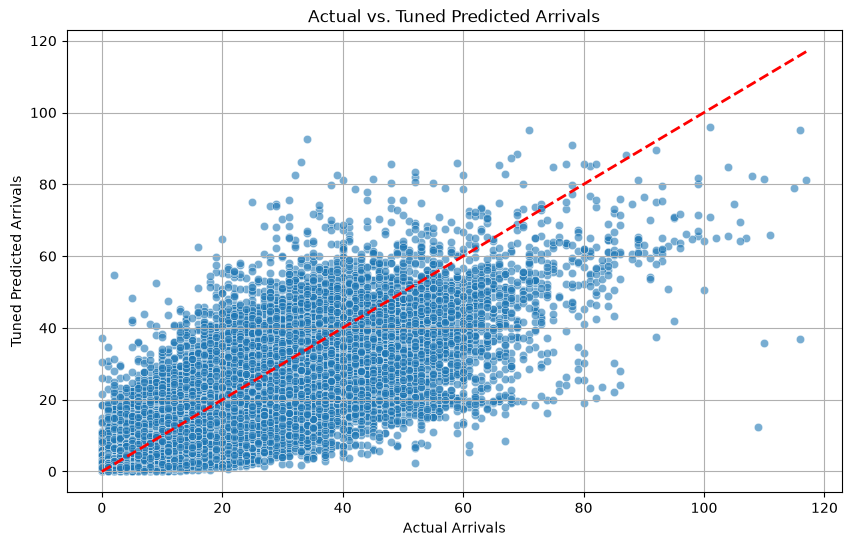

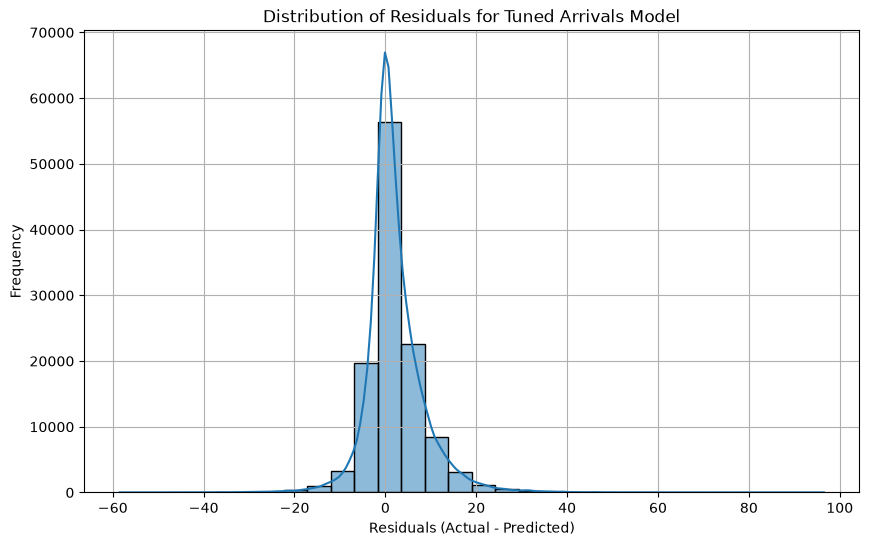

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Scatter Plot for Actual vs. Tuned Predicted Arrivals ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_arrivals, y=y_pred_arrivals_tuned, alpha=0.6)
plt.plot([min(y_test_arrivals), max(y_test_arrivals)], [min(y_test_arrivals), max(y_test_arrivals)], color='red', linestyle='--', lw=2)
plt.title('Actual vs. Tuned Predicted Arrivals')
plt.xlabel('Actual Arrivals')
plt.ylabel('Tuned Predicted Arrivals')
plt.grid(True)
plt.show()

# --- Residuals Plot for Tuned Arrivals Model ---
residuals_arrivals_tuned = y_test_arrivals - y_pred_arrivals_tuned
plt.figure(figsize=(10, 6))
sns.histplot(residuals_arrivals_tuned, bins=30, kde=True)
plt.title('Distribution of Residuals for Tuned Arrivals Model')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

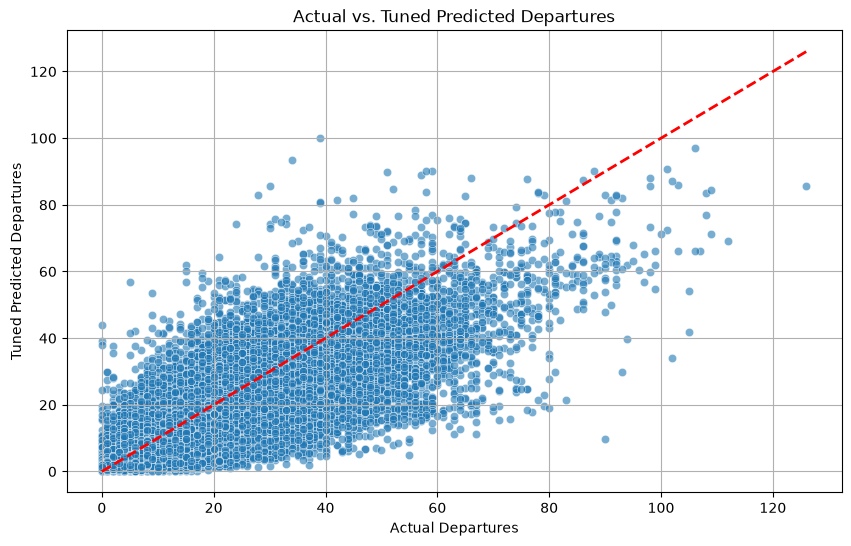

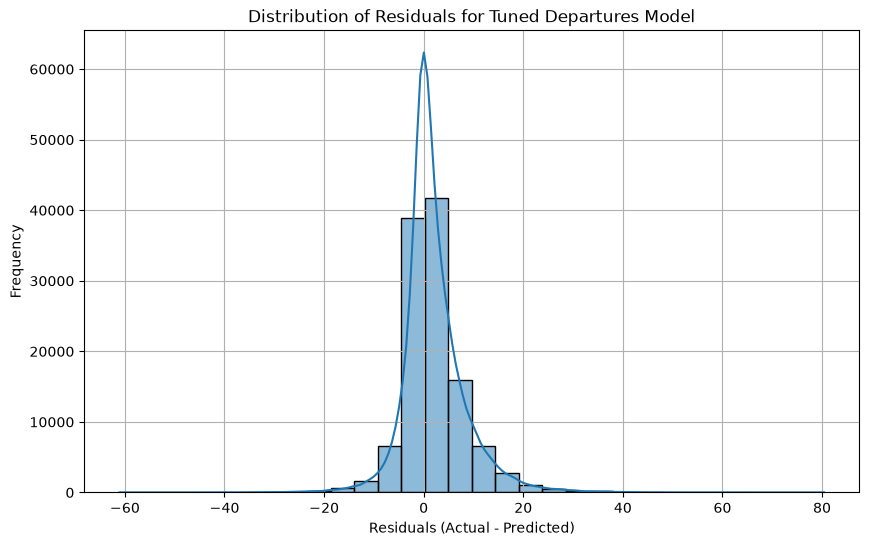

In [43]:
# --- Scatter Plot for Actual vs. Tuned Predicted Departures ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_departures, y=y_pred_departures_tuned, alpha=0.6)
plt.plot([min(y_test_departures), max(y_test_departures)], [min(y_test_departures), max(y_test_departures)], color='red', linestyle='--', lw=2)
plt.title('Actual vs. Tuned Predicted Departures')
plt.xlabel('Actual Departures')
plt.ylabel('Tuned Predicted Departures')
plt.grid(True)
plt.show()

# --- Residuals Plot for Tuned Departures Model ---
residuals_departures_tuned = y_test_departures - y_pred_departures_tuned
plt.figure(figsize=(10, 6))
sns.histplot(residuals_departures_tuned, bins=30, kde=True)
plt.title('Distribution of Residuals for Tuned Departures Model')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### going back to the feature importance models.

In [44]:
# Identify the top 3 features for the Arrivals model
feature_importances_arrivals_df = pd.DataFrame({
    'feature': X_train_arrivals.columns,
    'importance': xgb_arrivals_model.feature_importances_
}).sort_values(by='importance', ascending=False)

top_3_features_arrivals = feature_importances_arrivals_df.head(3)['feature'].tolist()

# Map original feature names to descriptive influence names
# feature_name_map = {
#     'degree_centrality_out': 'Station Departure Hub Score',
#     'precip': 'Daily Precipitation',
#     'min_temp': 'Minimum Daily Temperature'
# }

In [45]:
# Filter X_train and X_test to include only the top 3 features
X_train_arrivals_top3 = X_train_arrivals[top_3_features_arrivals]
X_test_arrivals_top3 = X_test_arrivals[top_3_features_arrivals]

print(f"Top 3 features for Arrivals model (original names): {top_3_features_arrivals}")
# print(f"Top 3 features for Arrivals model (descriptive names): {[feature_name_map.get(f, f) for f in top_3_features_arrivals]}")
print(f"X_train_arrivals_top3 shape: {X_train_arrivals_top3.shape}")

Top 3 features for Arrivals model (original names): ['eigenvector_centrality_weighted', 'max_temp', 'month']
X_train_arrivals_top3 shape: (332307, 3)


In [46]:
# Initialize and train a new XGBoost Regressor for Arrivals with only the top 3 features
xgb_arrivals_top3_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

print("\nTraining XGBoost model for Arrivals with top 3 features...")
xgb_arrivals_top3_model.fit(X_train_arrivals_top3, y_train_arrivals)
print("XGBoost model for Arrivals with top 3 features training complete.")


Training XGBoost model for Arrivals with top 3 features...
XGBoost model for Arrivals with top 3 features training complete.


In [47]:
# Make predictions with the top 3 features model
y_pred_arrivals_top3_normal = xgb_arrivals_top3_model.predict(X_test_arrivals_top3)

# Ensure non-negative predictions for counts
y_pred_arrivals_top3_normal[y_pred_arrivals_top3_normal < 0] = 0

# Apply different rounding methods
y_pred_arrivals_top3_standard_rounded = np.round(y_pred_arrivals_top3_normal)
y_pred_arrivals_top3_standard_rounded[y_pred_arrivals_top3_standard_rounded < 0] = 0

y_pred_arrivals_top3_floor_rounded = np.floor(y_pred_arrivals_top3_normal)
y_pred_arrivals_top3_floor_rounded[y_pred_arrivals_top3_floor_rounded < 0] = 0

y_pred_arrivals_top3_ceil_rounded = np.ceil(y_pred_arrivals_top3_normal)
y_pred_arrivals_top3_ceil_rounded[y_pred_arrivals_top3_ceil_rounded < 0] = 0

Evaluate the model with all four prediction types

In [48]:
# 1. Normal Predictions
mae_top3_normal = mean_absolute_error(y_test_arrivals, y_pred_arrivals_top3_normal)
r2_top3_normal = r2_score(y_test_arrivals, y_pred_arrivals_top3_normal)

print("\n--- XGBoost Model Performance (Arrivals - Top 3 Features - Normal Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_top3_normal:.3f}")
print(f"R-squared (R2): {r2_top3_normal:.3f}")

# 2. Standard Rounded Predictions
mae_top3_standard_rounded = mean_absolute_error(y_test_arrivals, y_pred_arrivals_top3_standard_rounded)
r2_top3_standard_rounded = r2_score(y_test_arrivals, y_pred_arrivals_top3_standard_rounded)

print("\n--- XGBoost Model Performance (Arrivals - Top 3 Features - Standard Rounded Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_top3_standard_rounded:.3f}")
print(f"R-squared (R2): {r2_top3_standard_rounded:.3f}")

# 3. Floor Rounded Predictions
mae_top3_floor_rounded = mean_absolute_error(y_test_arrivals, y_pred_arrivals_top3_floor_rounded)
r2_top3_floor_rounded = r2_score(y_test_arrivals, y_pred_arrivals_top3_floor_rounded)

print("\n--- XGBoost Model Performance (Arrivals - Top 3 Features - Floor Rounded Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_top3_floor_rounded:.3f}")
print(f"R-squared (R2): {r2_top3_floor_rounded:.3f}")

# 4. Ceiling Rounded Predictions
mae_top3_ceil_rounded = mean_absolute_error(y_test_arrivals, y_pred_arrivals_top3_ceil_rounded)
r2_top3_ceil_rounded = r2_score(y_test_arrivals, y_pred_arrivals_top3_ceil_rounded)

print("\n--- XGBoost Model Performance (Arrivals - Top 3 Features - Ceiling Rounded Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_top3_ceil_rounded:.3f}")
print(f"R-squared (R2): {r2_top3_ceil_rounded:.3f}")


--- XGBoost Model Performance (Arrivals - Top 3 Features - Normal Predictions) ---
Mean Absolute Error (MAE): 4.901
R-squared (R2): 0.639

--- XGBoost Model Performance (Arrivals - Top 3 Features - Standard Rounded Predictions) ---
Mean Absolute Error (MAE): 4.894
R-squared (R2): 0.638

--- XGBoost Model Performance (Arrivals - Top 3 Features - Floor Rounded Predictions) ---
Mean Absolute Error (MAE): 5.002
R-squared (R2): 0.622

--- XGBoost Model Performance (Arrivals - Top 3 Features - Ceiling Rounded Predictions) ---
Mean Absolute Error (MAE): 4.832
R-squared (R2): 0.651


now for departures

In [49]:
# Identify the top 3 features for the Departures model
feature_importances_departures_df = pd.DataFrame({
    'feature': X_train_departures.columns,
    'importance': xgb_departures_model.feature_importances_
}).sort_values(by='importance', ascending=False)

top_3_features_departures = feature_importances_departures_df.head(3)['feature'].tolist()

# # Map original feature names to descriptive influence names
# feature_name_map_departures = {
#     'min_temp': 'Minimum Daily Temperature',
#     'degree_centrality_out': 'Station Departure Hub Score',
#     'closeness_centrality_unweighted': 'Unweighted Closeness Centrality'
# }

In [50]:
# Filter X_train and X_test to include only the top 3 features for departures
X_train_departures_top3 = X_train_departures[top_3_features_departures]
X_test_departures_top3 = X_test_departures[top_3_features_departures]

print(f"Top 3 features for Departures model (original names): {top_3_features_departures}")
# print(f"Top 3 features for Departures model (descriptive names): {[feature_name_map_departures.get(f, f) for f in top_3_features_departures]}")
print(f"X_train_departures_top3 shape: {X_train_departures_top3.shape}")

Top 3 features for Departures model (original names): ['eigenvector_centrality_weighted', 'max_temp', 'month']
X_train_departures_top3 shape: (332307, 3)


In [51]:
# Initialize and train a new XGBoost Regressor for Departures with only the top 3 features
xgb_departures_top3_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

print("\nTraining XGBoost model for Departures with top 3 features...")
xgb_departures_top3_model.fit(X_train_departures_top3, y_train_departures)
print("XGBoost model for Departures with top 3 features training complete.")



Training XGBoost model for Departures with top 3 features...
XGBoost model for Departures with top 3 features training complete.


In [52]:
# Make predictions with the top 3 features model
y_pred_departures_top3_normal = xgb_departures_top3_model.predict(X_test_departures_top3)

# Ensure non-negative predictions for counts
y_pred_departures_top3_normal[y_pred_departures_top3_normal < 0] = 0

# Apply different rounding methods
y_pred_departures_top3_standard_rounded = np.round(y_pred_departures_top3_normal)
y_pred_departures_top3_standard_rounded[y_pred_departures_top3_standard_rounded < 0] = 0

y_pred_departures_top3_floor_rounded = np.floor(y_pred_departures_top3_normal)
y_pred_departures_top3_floor_rounded[y_pred_departures_top3_floor_rounded < 0] = 0

y_pred_departures_top3_ceil_rounded = np.ceil(y_pred_departures_top3_normal)
y_pred_departures_top3_ceil_rounded[y_pred_departures_top3_ceil_rounded < 0] = 0

Evaluate the model with all four prediction types

In [53]:
# 1. Normal Predictions
mae_top3_normal_departures = mean_absolute_error(y_test_departures, y_pred_departures_top3_normal)
r2_top3_normal_departures = r2_score(y_test_departures, y_pred_departures_top3_normal)

print("\n--- XGBoost Model Performance (Departures - Top 3 Features - Normal Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_top3_normal_departures:.3f}")
print(f"R-squared (R2): {r2_top3_normal_departures:.3f}")

# 2. Standard Rounded Predictions
mae_top3_standard_rounded_departures = mean_absolute_error(y_test_departures, y_pred_departures_top3_standard_rounded)
r2_top3_standard_rounded_departures = r2_score(y_test_departures, y_pred_departures_top3_standard_rounded)

print("\n--- XGBoost Model Performance (Departures - Top 3 Features - Standard Rounded Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_top3_standard_rounded_departures:.3f}")
print(f"R-squared (R2): {r2_top3_standard_rounded_departures:.3f}")

# 3. Floor Rounded Predictions
mae_top3_floor_rounded_departures = mean_absolute_error(y_test_departures, y_pred_departures_top3_floor_rounded)
r2_top3_floor_rounded_departures = r2_score(y_test_departures, y_pred_departures_top3_floor_rounded)

print("\n--- XGBoost Model Performance (Departures - Top 3 Features - Floor Rounded Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_top3_floor_rounded_departures:.3f}")
print(f"R-squared (R2): {r2_top3_floor_rounded_departures:.3f}")

# 4. Ceiling Rounded Predictions
mae_top3_ceil_rounded_departures = mean_absolute_error(y_test_departures, y_pred_departures_top3_ceil_rounded)
r2_top3_ceil_rounded_departures = r2_score(y_test_departures, y_pred_departures_top3_ceil_rounded)

print("\n--- XGBoost Model Performance (Departures - Top 3 Features - Ceiling Rounded Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_top3_ceil_rounded_departures:.3f}")
print(f"R-squared (R2): {r2_top3_ceil_rounded_departures:.3f}")


--- XGBoost Model Performance (Departures - Top 3 Features - Normal Predictions) ---
Mean Absolute Error (MAE): 4.807
R-squared (R2): 0.653

--- XGBoost Model Performance (Departures - Top 3 Features - Standard Rounded Predictions) ---
Mean Absolute Error (MAE): 4.795
R-squared (R2): 0.653

--- XGBoost Model Performance (Departures - Top 3 Features - Floor Rounded Predictions) ---
Mean Absolute Error (MAE): 4.905
R-squared (R2): 0.637

--- XGBoost Model Performance (Departures - Top 3 Features - Ceiling Rounded Predictions) ---
Mean Absolute Error (MAE): 4.746
R-squared (R2): 0.665


### now, for eigenvector manipulation -- squared weights

In [54]:
# Use weighted eigenvector centrality, where higher trip count means more influence
# Applying squaring to the weight as requested
try:
    eigenvector_weighted = nx.eigenvector_centrality(G, weight=lambda x: x['weight']**2, max_iter=1000, tol=1e-06)
except nx.PowerIterationFailedConvergence:
    print("Eigenvector centrality did not converge for some nodes. Assigning 0 to non-converged nodes.")
    eigenvector_weighted = {node: 0 for node in G.nodes()}
except Exception as e:
    print(f"Error calculating eigenvector centrality: {e}. Assigning 0 to all nodes.")
    eigenvector_weighted = {node: 0 for node in G.nodes()}

Re-calculating Centrality with Squared Eigenvector Weights

In [55]:
# The eigenvector_weighted was already re-calculated in the previous cell with squared weights.
# Now, re-create the station_centrality_df using this updated eigenvector_weighted.
centrality_measures_squared_eigen = {
    'station_id': [],
    'degree_centrality_in': [],
    'degree_centrality_out': [],
    'betweenness_centrality_unweighted': [],
    'closeness_centrality_unweighted': [],
    'eigenvector_centrality_weighted': []
}

for station_id in G.nodes():
    centrality_measures_squared_eigen['station_id'].append(station_id)
    centrality_measures_squared_eigen['degree_centrality_in'].append(in_degree_centrality.get(station_id, 0))
    centrality_measures_squared_eigen['degree_centrality_out'].append(out_degree_centrality.get(station_id, 0))
    centrality_measures_squared_eigen['betweenness_centrality_unweighted'].append(betweenness_unweighted.get(station_id, 0))
    centrality_measures_squared_eigen['closeness_centrality_unweighted'].append(closeness_unweighted.get(station_id, 0))
    centrality_measures_squared_eigen['eigenvector_centrality_weighted'].append(eigenvector_weighted.get(station_id, 0))

station_centrality_df_squared_eigen = pd.DataFrame(centrality_measures_squared_eigen)

print("\n---  ---")


---  ---


Preparing New Modeling DataFrame with Squared Eigenvector Centrality

In [56]:
# Create a new modeling_df incorporating the updated centrality measures
modeling_df_squared_eigen = daily_station_activity.copy()

# Add time-based features (already calculated in original modeling_df creation flow)
modeling_df_squared_eigen['date'] = pd.to_datetime(modeling_df_squared_eigen['date']) # Ensure datetime type
modeling_df_squared_eigen['weekday'] = modeling_df_squared_eigen['date'].dt.weekday # Monday=0, Sunday=6
modeling_df_squared_eigen['dayofyear'] = modeling_df_squared_eigen['date'].dt.dayofyear
modeling_df_squared_eigen['month'] = modeling_df_squared_eigen['date'].dt.month
modeling_df_squared_eigen['is_weekend'] = modeling_df_squared_eigen['date'].dt.weekday.isin([5, 6])

# Merge new centrality measures
modeling_df_squared_eigen = pd.merge(modeling_df_squared_eigen, station_centrality_df_squared_eigen, on='station_id', how='left')

# Merge weather features (already calculated in original modeling_df creation flow)
modeling_df_squared_eigen = pd.merge(modeling_df_squared_eigen, weather_features, on='date', how='left')

# Handle potential NaNs after merging (as done previously)
for col in centrality_cols:
    modeling_df_squared_eigen[col] = modeling_df_squared_eigen[col].fillna(0)

modeling_df_squared_eigen.sort_values(by=['date', 'station_id'], inplace=True)
modeling_df_squared_eigen[weather_features.columns.drop('date')] = modeling_df_squared_eigen[weather_features.columns.drop('date')].ffill()
modeling_df_squared_eigen[weather_features.columns.drop('date')] = modeling_df_squared_eigen[weather_features.columns.drop('date')].fillna(0)

print("Head of new modeling_df_squared_eigen:")
display(modeling_df_squared_eigen.head())


Head of new modeling_df_squared_eigen:


,date,station_id,departures,arrivals,net_change,weekday,dayofyear,month,is_weekend,degree_centrality_in,degree_centrality_out,betweenness_centrality_unweighted,closeness_centrality_unweighted,eigenvector_centrality_weighted,avg_wind,precip,snow,snow_ground,max_temp,min_temp
0,2020-01-01,3004,2.0,2.0,0.0,2,1,1,False,0.610465,0.607558,0.000245,0.714643,0.049813,9.17,0.0,0.0,0.0,42.0,29.0
1,2020-01-01,3005,10.0,2.0,-8.0,2,1,1,False,0.834302,0.834302,0.001171,0.853601,0.064764,9.17,0.0,0.0,0.0,42.0,29.0
2,2020-01-01,3006,3.0,4.0,1.0,2,1,1,False,0.857558,0.845930,0.002645,0.871201,0.065278,9.17,0.0,0.0,0.0,42.0,29.0
3,2020-01-01,3007,3.0,7.0,4.0,2,1,1,False,0.886628,0.895349,0.002138,0.894249,0.067425,9.17,0.0,0.0,0.0,42.0,29.0
4,2020-01-01,3008,1.0,1.0,0.0,2,1,1,False,0.694767,0.764535,0.001102,0.761320,0.054023,9.17,0.0,0.0,0.0,42.0,29.0


###### arrival model

Preparing Data for Arrivals Model (Squared Eigenvector)

In [57]:
# Define the split dates (using previously defined train_end_date and test_start_date)

# Filter data for training and testing periods from the new modeling_df
train_df_squared_eigen = modeling_df_squared_eigen[modeling_df_squared_eigen['date'] <= train_end_date]
test_df_squared_eigen = modeling_df_squared_eigen[modeling_df_squared_eigen['date'] >= test_start_date]

# Feature columns (all features, excluding target and identifiers)
feature_cols_all = modeling_df_squared_eigen.drop(columns=['date', 'departures', 'arrivals', 'net_change', 'station_id']).columns

X_train_arrivals_squared_eigen = train_df_squared_eigen[feature_cols_all]
y_train_arrivals_squared_eigen = train_df_squared_eigen['arrivals']

X_test_arrivals_squared_eigen = test_df_squared_eigen[feature_cols_all]
y_test_arrivals_squared_eigen = test_df_squared_eigen['arrivals']

# Convert 'is_weekend' to int
X_train_arrivals_squared_eigen['is_weekend'] = X_train_arrivals_squared_eigen['is_weekend'].astype(int)
X_test_arrivals_squared_eigen['is_weekend'] = X_test_arrivals_squared_eigen['is_weekend'].astype(int)

print(f"X_train_arrivals_squared_eigen shape: {X_train_arrivals_squared_eigen.shape}")

X_train_arrivals_squared_eigen shape: (332307, 15)


Training XGBoost Model for Arrivals (Squared Eigenvector)

In [58]:
# Initialize and train the XGBoost Regressor for Arrivals
xgb_arrivals_model_squared_eigen = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
xgb_arrivals_model_squared_eigen.fit(X_train_arrivals_squared_eigen, y_train_arrivals_squared_eigen)
print("XGBoost model for Arrivals with squared eigenvector centrality training complete.")

XGBoost model for Arrivals with squared eigenvector centrality training complete.


In [59]:
# Make predictions
y_pred_arrivals_squared_eigen_normal = xgb_arrivals_model_squared_eigen.predict(X_test_arrivals_squared_eigen)
y_pred_arrivals_squared_eigen_normal[y_pred_arrivals_squared_eigen_normal < 0] = 0

y_pred_arrivals_squared_eigen_standard_rounded = np.round(y_pred_arrivals_squared_eigen_normal)
y_pred_arrivals_squared_eigen_standard_rounded[y_pred_arrivals_squared_eigen_standard_rounded < 0] = 0

y_pred_arrivals_squared_eigen_floor_rounded = np.floor(y_pred_arrivals_squared_eigen_normal)
y_pred_arrivals_squared_eigen_floor_rounded[y_pred_arrivals_squared_eigen_floor_rounded < 0] = 0

y_pred_arrivals_squared_eigen_ceil_rounded = np.ceil(y_pred_arrivals_squared_eigen_normal)
y_pred_arrivals_squared_eigen_ceil_rounded[y_pred_arrivals_squared_eigen_ceil_rounded < 0] = 0

Evaluating Arrivals Model Performance (Squared Eigenvector)

In [60]:
mae_arrivals_sq_eigen_normal = mean_absolute_error(y_test_arrivals_squared_eigen, y_pred_arrivals_squared_eigen_normal)
r2_arrivals_sq_eigen_normal = r2_score(y_test_arrivals_squared_eigen, y_pred_arrivals_squared_eigen_normal)
print(f"MAE (Normal): {mae_arrivals_sq_eigen_normal:.3f}, \n R2 (Normal): {r2_arrivals_sq_eigen_normal:.3f}\n")

mae_arrivals_sq_eigen_standard_rounded = mean_absolute_error(y_test_arrivals_squared_eigen, y_pred_arrivals_squared_eigen_standard_rounded)
r2_arrivals_sq_eigen_standard_rounded = r2_score(y_test_arrivals_squared_eigen, y_pred_arrivals_squared_eigen_standard_rounded)
print(f"MAE (Standard Rounded): {mae_arrivals_sq_eigen_standard_rounded:.3f}, \n R2 (Standard Rounded): {r2_arrivals_sq_eigen_standard_rounded:.3f}\n")

mae_arrivals_sq_eigen_floor_rounded = mean_absolute_error(y_test_arrivals_squared_eigen, y_pred_arrivals_squared_eigen_floor_rounded)
r2_arrivals_sq_eigen_floor_rounded = r2_score(y_test_arrivals_squared_eigen, y_pred_arrivals_squared_eigen_floor_rounded)
print(f"MAE (Floor Rounded): {mae_arrivals_sq_eigen_floor_rounded:.3f}, \n R2 (Floor Rounded): {r2_arrivals_sq_eigen_floor_rounded:.3f}\n")

mae_arrivals_sq_eigen_ceil_rounded = mean_absolute_error(y_test_arrivals_squared_eigen, y_pred_arrivals_squared_eigen_ceil_rounded)
r2_arrivals_sq_eigen_ceil_rounded = r2_score(y_test_arrivals_squared_eigen, y_pred_arrivals_squared_eigen_ceil_rounded)
print(f"MAE (Ceiling Rounded): {mae_arrivals_sq_eigen_ceil_rounded:.3f}, \n R2 (Ceiling Rounded): {r2_arrivals_sq_eigen_ceil_rounded:.3f}\n")

MAE (Normal): 4.827, 
 R2 (Normal): 0.654

MAE (Standard Rounded): 4.819, 
 R2 (Standard Rounded): 0.653

MAE (Floor Rounded): 4.904, 
 R2 (Floor Rounded): 0.640

MAE (Ceiling Rounded): 4.780, 
 R2 (Ceiling Rounded): 0.663



 ###### departure model

Preparing Data for Departures Model (Squared Eigenvector)

In [61]:
X_train_departures_squared_eigen = train_df_squared_eigen[feature_cols_all]
y_train_departures_squared_eigen = train_df_squared_eigen['departures']

X_test_departures_squared_eigen = test_df_squared_eigen[feature_cols_all]
y_test_departures_squared_eigen = test_df_squared_eigen['departures']

X_train_departures_squared_eigen['is_weekend'] = X_train_departures_squared_eigen['is_weekend'].astype(int)
X_test_departures_squared_eigen['is_weekend'] = X_test_departures_squared_eigen['is_weekend'].astype(int)

print(f"X_train_departures_squared_eigen shape: {X_train_departures_squared_eigen.shape}")

X_train_departures_squared_eigen shape: (332307, 15)


In [62]:
xgb_departures_model_squared_eigen = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
xgb_departures_model_squared_eigen.fit(X_train_departures_squared_eigen, y_train_departures_squared_eigen)
print("XGBoost model for Departures with squared eigenvector centrality training complete.")

XGBoost model for Departures with squared eigenvector centrality training complete.


Training XGBoost Model for Departures (Squared Eigenvector)

In [63]:
# Make predictions
y_pred_departures_squared_eigen_normal = xgb_departures_model_squared_eigen.predict(X_test_departures_squared_eigen)
y_pred_departures_squared_eigen_normal[y_pred_departures_squared_eigen_normal < 0] = 0

y_pred_departures_squared_eigen_standard_rounded = np.round(y_pred_departures_squared_eigen_normal)
y_pred_departures_squared_eigen_standard_rounded[y_pred_departures_squared_eigen_standard_rounded < 0] = 0

y_pred_departures_squared_eigen_floor_rounded = np.floor(y_pred_departures_squared_eigen_normal)
y_pred_departures_squared_eigen_floor_rounded[y_pred_departures_squared_eigen_floor_rounded < 0] = 0

y_pred_departures_squared_eigen_ceil_rounded = np.ceil(y_pred_departures_squared_eigen_normal)
y_pred_departures_squared_eigen_ceil_rounded[y_pred_departures_squared_eigen_ceil_rounded < 0] = 0

Evaluating Departures Model Performance (Squared Eigenvector)

In [64]:

mae_departures_sq_eigen_normal = mean_absolute_error(y_test_departures_squared_eigen, y_pred_departures_squared_eigen_normal)
r2_departures_sq_eigen_normal = r2_score(y_test_departures_squared_eigen, y_pred_departures_squared_eigen_normal)
print(f"MAE (Normal): {mae_departures_sq_eigen_normal:.3f}, \n R2 (Normal): {r2_departures_sq_eigen_normal:.3f}\n")

mae_departures_sq_eigen_standard_rounded = mean_absolute_error(y_test_departures_squared_eigen, y_pred_departures_squared_eigen_standard_rounded)
r2_departures_sq_eigen_standard_rounded = r2_score(y_test_departures_squared_eigen, y_pred_departures_squared_eigen_standard_rounded)
print(f"MAE (Standard Rounded): {mae_departures_sq_eigen_standard_rounded:.3f}, \n R2 (Standard Rounded): {r2_departures_sq_eigen_standard_rounded:.3f}\n")

mae_departures_sq_eigen_floor_rounded = mean_absolute_error(y_test_departures_squared_eigen, y_pred_departures_squared_eigen_floor_rounded)
r2_departures_sq_eigen_floor_rounded = r2_score(y_test_departures_squared_eigen, y_pred_departures_squared_eigen_floor_rounded)
print(f"MAE (Floor Rounded): {mae_departures_sq_eigen_floor_rounded:.3f}, \n R2 (Floor Rounded): {r2_departures_sq_eigen_floor_rounded:.3f}\n")

mae_departures_sq_eigen_ceil_rounded = mean_absolute_error(y_test_departures_squared_eigen, y_pred_departures_squared_eigen_ceil_rounded)
r2_departures_sq_eigen_ceil_rounded = r2_score(y_test_departures_squared_eigen, y_pred_departures_squared_eigen_ceil_rounded)
print(f"MAE (Ceiling Rounded): {mae_departures_sq_eigen_ceil_rounded:.3f}, \n R2 (Ceiling Rounded): {r2_departures_sq_eigen_ceil_rounded:.3f}\n")


MAE (Normal): 4.782, 
 R2 (Normal): 0.660

MAE (Standard Rounded): 4.775, 
 R2 (Standard Rounded): 0.660

MAE (Floor Rounded): 4.861, 
 R2 (Floor Rounded): 0.647

MAE (Ceiling Rounded): 4.730, 
 R2 (Ceiling Rounded): 0.670



### now, for eigenvector manipulation -- squared ROOTED weights

In [65]:
# Use weighted eigenvector centrality, where higher trip count means more influence
# Applying square rooting to the weight as requested
try:
    eigenvector_square_rooted = nx.eigenvector_centrality(G, weight=lambda x: x['weight']**0.5, max_iter=1000, tol=1e-06)
except nx.PowerIterationFailedConvergence:
    print("Eigenvector centrality did not converge for some nodes. Assigning 0 to non-converged nodes.")
    eigenvector_square_rooted = {node: 0 for node in G.nodes()}
except Exception as e:
    print(f"Error calculating eigenvector centrality: {e}. Assigning 0 to all nodes.")
    eigenvector_square_rooted = {node: 0 for node in G.nodes()}

Re-calculating Centrality with Squared Eigenvector Weights

In [66]:
# The eigenvector_square_rooted was already re-calculated in the previous cell.
# Now, re-create the station_centrality_df using this updated eigenvector_square_rooted.
centrality_measures_square_rooted_eigen = {
    'station_id': [],
    'degree_centrality_in': [],
    'degree_centrality_out': [],
    'betweenness_centrality_unweighted': [],
    'closeness_centrality_unweighted': [],
    'eigenvector_centrality_weighted': []
}

for station_id in G.nodes():
    centrality_measures_square_rooted_eigen['station_id'].append(station_id)
    centrality_measures_square_rooted_eigen['degree_centrality_in'].append(in_degree_centrality.get(station_id, 0))
    centrality_measures_square_rooted_eigen['degree_centrality_out'].append(out_degree_centrality.get(station_id, 0))
    centrality_measures_square_rooted_eigen['betweenness_centrality_unweighted'].append(betweenness_unweighted.get(station_id, 0))
    centrality_measures_square_rooted_eigen['closeness_centrality_unweighted'].append(closeness_unweighted.get(station_id, 0))
    centrality_measures_square_rooted_eigen['eigenvector_centrality_weighted'].append(eigenvector_square_rooted.get(station_id, 0))

station_centrality_df_square_rooted_eigen = pd.DataFrame(centrality_measures_square_rooted_eigen)

print("--- Station Centrality DataFrame with Square-Rooted Eigenvector Updated ---")

--- Station Centrality DataFrame with Square-Rooted Eigenvector Updated ---


Preparing New Modeling DataFrame with Squared Eigenvector Centrality

In [67]:
# Create a new modeling_df incorporating the updated centrality measures
modeling_df_square_rooted_eigen = daily_station_activity.copy()

# Add time-based features (already calculated in original modeling_df creation flow)
modeling_df_square_rooted_eigen['date'] = pd.to_datetime(modeling_df_square_rooted_eigen['date']) # Ensure datetime type
modeling_df_square_rooted_eigen['weekday'] = modeling_df_square_rooted_eigen['date'].dt.weekday # Monday=0, Sunday=6
modeling_df_square_rooted_eigen['dayofyear'] = modeling_df_square_rooted_eigen['date'].dt.dayofyear
modeling_df_square_rooted_eigen['month'] = modeling_df_square_rooted_eigen['date'].dt.month
modeling_df_square_rooted_eigen['is_weekend'] = modeling_df_square_rooted_eigen['date'].dt.weekday.isin([5, 6])

# Merge new centrality measures
modeling_df_square_rooted_eigen = pd.merge(modeling_df_square_rooted_eigen, station_centrality_df_square_rooted_eigen, on='station_id', how='left')

# Merge weather features (already calculated in original modeling_df creation flow)
modeling_df_square_rooted_eigen = pd.merge(modeling_df_square_rooted_eigen, weather_features, on='date', how='left')

# Handle potential NaNs after merging (as done previously)
for col in centrality_cols:
    modeling_df_square_rooted_eigen[col] = modeling_df_square_rooted_eigen[col].fillna(0)

modeling_df_square_rooted_eigen.sort_values(by=['date', 'station_id'], inplace=True)
modeling_df_square_rooted_eigen[weather_features.columns.drop('date')] = modeling_df_square_rooted_eigen[weather_features.columns.drop('date')].ffill()
modeling_df_square_rooted_eigen[weather_features.columns.drop('date')] = modeling_df_square_rooted_eigen[weather_features.columns.drop('date')].fillna(0)

print("Head of new modeling_df_square_rooted_eigen:")
display(modeling_df_square_rooted_eigen.head())

Head of new modeling_df_square_rooted_eigen:


,date,station_id,departures,arrivals,net_change,weekday,dayofyear,month,is_weekend,degree_centrality_in,degree_centrality_out,betweenness_centrality_unweighted,closeness_centrality_unweighted,eigenvector_centrality_weighted,avg_wind,precip,snow,snow_ground,max_temp,min_temp
0,2020-01-01,3004,2.0,2.0,0.0,2,1,1,False,0.610465,0.607558,0.000245,0.714643,0.049813,9.17,0.0,0.0,0.0,42.0,29.0
1,2020-01-01,3005,10.0,2.0,-8.0,2,1,1,False,0.834302,0.834302,0.001171,0.853601,0.064764,9.17,0.0,0.0,0.0,42.0,29.0
2,2020-01-01,3006,3.0,4.0,1.0,2,1,1,False,0.857558,0.845930,0.002645,0.871201,0.065278,9.17,0.0,0.0,0.0,42.0,29.0
3,2020-01-01,3007,3.0,7.0,4.0,2,1,1,False,0.886628,0.895349,0.002138,0.894249,0.067425,9.17,0.0,0.0,0.0,42.0,29.0
4,2020-01-01,3008,1.0,1.0,0.0,2,1,1,False,0.694767,0.764535,0.001102,0.761320,0.054023,9.17,0.0,0.0,0.0,42.0,29.0


###### arrival model

Preparing Data for Arrivals Model (Squared Eigenvector)

In [68]:
# Define the split dates (using previously defined train_end_date and test_start_date)

# Filter data for training and testing periods from the new modeling_df
train_df_square_rooted_eigen = modeling_df_square_rooted_eigen[modeling_df_square_rooted_eigen['date'] <= train_end_date]
test_df_square_rooted_eigen = modeling_df_square_rooted_eigen[modeling_df_square_rooted_eigen['date'] >= test_start_date]

# Feature columns (all features, excluding target and identifiers)
feature_cols_all_square_rooted_eigen = modeling_df_square_rooted_eigen.drop(columns=['date', 'departures', 'arrivals', 'net_change', 'station_id']).columns

X_train_arrivals_square_rooted_eigen = train_df_square_rooted_eigen[feature_cols_all_square_rooted_eigen]
y_train_arrivals_square_rooted_eigen = train_df_square_rooted_eigen['arrivals']

X_test_arrivals_square_rooted_eigen = test_df_square_rooted_eigen[feature_cols_all_square_rooted_eigen]
y_test_arrivals_square_rooted_eigen = test_df_square_rooted_eigen['arrivals']

# # Convert 'is_weekend' to int
# X_train_arrivals_square_rooted_eigen.loc[:, 'is_weekend'] = X_train_arrivals_square_rooted_eigen['is_weekend'].astype(int)
# X_test_arrivals_square_rooted_eigen.loc[:, 'is_weekend'] = X_test_arrivals_square_rooted_eigen['is_weekend'].astype(int)

print(f"X_train_arrivals_square_rooted_eigen shape: {X_train_arrivals_square_rooted_eigen.shape}")

X_train_arrivals_square_rooted_eigen shape: (332307, 15)


Training XGBoost Model for Arrivals (Squared Eigenvector)

In [69]:
# Initialize and train the XGBoost Regressor for Arrivals
xgb_arrivals_model_square_rooted_eigen = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
xgb_arrivals_model_square_rooted_eigen.fit(X_train_arrivals_square_rooted_eigen, y_train_arrivals_square_rooted_eigen)
print("XGBoost model for Arrivals with square-rooted eigenvector centrality training complete.")

XGBoost model for Arrivals with square-rooted eigenvector centrality training complete.


In [70]:
# Make predictions
y_pred_arrivals_square_rooted_eigen_normal = xgb_arrivals_model_square_rooted_eigen.predict(X_test_arrivals_square_rooted_eigen)
y_pred_arrivals_square_rooted_eigen_normal[y_pred_arrivals_square_rooted_eigen_normal < 0] = 0

y_pred_arrivals_square_rooted_eigen_standard_rounded = np.round(y_pred_arrivals_square_rooted_eigen_normal)
y_pred_arrivals_square_rooted_eigen_standard_rounded[y_pred_arrivals_square_rooted_eigen_standard_rounded < 0] = 0

y_pred_arrivals_square_rooted_eigen_floor_rounded = np.floor(y_pred_arrivals_square_rooted_eigen_normal)
y_pred_arrivals_square_rooted_eigen_floor_rounded[y_pred_arrivals_square_rooted_eigen_floor_rounded < 0] = 0

y_pred_arrivals_square_rooted_eigen_ceil_rounded = np.ceil(y_pred_arrivals_square_rooted_eigen_normal)
y_pred_arrivals_square_rooted_eigen_ceil_rounded[y_pred_arrivals_square_rooted_eigen_ceil_rounded < 0] = 0

Evaluating Arrivals Model Performance (Squared Eigenvector)

In [71]:
mae_arrivals_sq_rooted_eigen_normal = mean_absolute_error(y_test_arrivals_square_rooted_eigen, y_pred_arrivals_square_rooted_eigen_normal)
r2_arrivals_sq_rooted_eigen_normal = r2_score(y_test_arrivals_square_rooted_eigen, y_pred_arrivals_square_rooted_eigen_normal)
print(f"MAE (Normal): {mae_arrivals_sq_rooted_eigen_normal:.3f}, \n R2 (Normal): {r2_arrivals_sq_rooted_eigen_normal:.3f}\n")

mae_arrivals_sq_rooted_eigen_standard_rounded = mean_absolute_error(y_test_arrivals_square_rooted_eigen, y_pred_arrivals_square_rooted_eigen_standard_rounded)
r2_arrivals_sq_rooted_eigen_standard_rounded = r2_score(y_test_arrivals_square_rooted_eigen, y_pred_arrivals_square_rooted_eigen_standard_rounded)
print(f"MAE (Standard Rounded): {mae_arrivals_sq_rooted_eigen_standard_rounded:.3f}, \n R2 (Standard Rounded): {r2_arrivals_sq_rooted_eigen_standard_rounded:.3f}\n")

mae_arrivals_sq_rooted_eigen_floor_rounded = mean_absolute_error(y_test_arrivals_square_rooted_eigen, y_pred_arrivals_square_rooted_eigen_floor_rounded)
r2_arrivals_sq_rooted_eigen_floor_rounded = r2_score(y_test_arrivals_square_rooted_eigen, y_pred_arrivals_square_rooted_eigen_floor_rounded)
print(f"MAE (Floor Rounded): {mae_arrivals_sq_rooted_eigen_floor_rounded:.3f}, \n R2 (Floor Rounded): {r2_arrivals_sq_rooted_eigen_floor_rounded:.3f}\n")

mae_arrivals_sq_rooted_eigen_ceil_rounded = mean_absolute_error(y_test_arrivals_square_rooted_eigen, y_pred_arrivals_square_rooted_eigen_ceil_rounded)
r2_arrivals_sq_rooted_eigen_ceil_rounded = r2_score(y_test_arrivals_square_rooted_eigen, y_pred_arrivals_square_rooted_eigen_ceil_rounded)
print(f"MAE (Ceiling Rounded): {mae_arrivals_sq_rooted_eigen_ceil_rounded:.3f}, \n R2 (Ceiling Rounded): {r2_arrivals_sq_rooted_eigen_ceil_rounded:.3f}\n")

MAE (Normal): 4.827, 
 R2 (Normal): 0.654

MAE (Standard Rounded): 4.819, 
 R2 (Standard Rounded): 0.653

MAE (Floor Rounded): 4.904, 
 R2 (Floor Rounded): 0.640

MAE (Ceiling Rounded): 4.780, 
 R2 (Ceiling Rounded): 0.663



 ###### departure model

Preparing Data for Departures Model (Squared Eigenvector)

In [72]:
X_train_departures_square_rooted_eigen = train_df_square_rooted_eigen[feature_cols_all_square_rooted_eigen]
y_train_departures_square_rooted_eigen = train_df_square_rooted_eigen['departures']

X_test_departures_square_rooted_eigen = test_df_square_rooted_eigen[feature_cols_all_square_rooted_eigen]
y_test_departures_square_rooted_eigen = test_df_square_rooted_eigen['departures']

# X_train_departures_square_rooted_eigen.loc[:, 'is_weekend'] = X_train_departures_square_rooted_eigen['is_weekend'].astype(int)
# X_test_departures_square_rooted_eigen.loc[:, 'is_weekend'] = X_test_departures_square_rooted_eigen['is_weekend'].astype(int)

print(f"X_train_departures_square_rooted_eigen shape: {X_train_departures_square_rooted_eigen.shape}")

X_train_departures_square_rooted_eigen shape: (332307, 15)


In [73]:
xgb_departures_model_square_rooted_eigen = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
xgb_departures_model_square_rooted_eigen.fit(X_train_departures_square_rooted_eigen, y_train_departures_square_rooted_eigen)
print("XGBoost model for Departures with square-rooted eigenvector centrality training complete.")

XGBoost model for Departures with square-rooted eigenvector centrality training complete.


Training XGBoost Model for Departures (Squared Eigenvector)

In [74]:
# Make predictions
y_pred_departures_square_rooted_eigen_normal = xgb_departures_model_square_rooted_eigen.predict(X_test_departures_square_rooted_eigen)
y_pred_departures_square_rooted_eigen_normal[y_pred_departures_square_rooted_eigen_normal < 0] = 0

y_pred_departures_square_rooted_eigen_standard_rounded = np.round(y_pred_departures_square_rooted_eigen_normal)
y_pred_departures_square_rooted_eigen_standard_rounded[y_pred_departures_square_rooted_eigen_standard_rounded < 0] = 0

y_pred_departures_square_rooted_eigen_floor_rounded = np.floor(y_pred_departures_square_rooted_eigen_normal)
y_pred_departures_square_rooted_eigen_floor_rounded[y_pred_departures_square_rooted_eigen_floor_rounded < 0] = 0

y_pred_departures_square_rooted_eigen_ceil_rounded = np.ceil(y_pred_departures_square_rooted_eigen_normal)
y_pred_departures_square_rooted_eigen_ceil_rounded[y_pred_departures_square_rooted_eigen_ceil_rounded < 0] = 0

Evaluating Departures Model Performance (Squared Eigenvector)

In [75]:
mae_departures_sq_rooted_eigen_normal = mean_absolute_error(y_test_departures_square_rooted_eigen, y_pred_departures_square_rooted_eigen_normal)
r2_departures_sq_rooted_eigen_normal = r2_score(y_test_departures_square_rooted_eigen, y_pred_departures_square_rooted_eigen_normal)
print(f"MAE (Normal): {mae_departures_sq_rooted_eigen_normal:.3f}, \n R2 (Normal): {r2_departures_sq_rooted_eigen_normal:.3f}\n")

mae_departures_sq_rooted_eigen_standard_rounded = mean_absolute_error(y_test_departures_square_rooted_eigen, y_pred_departures_square_rooted_eigen_standard_rounded)
r2_departures_sq_rooted_eigen_standard_rounded = r2_score(y_test_departures_square_rooted_eigen, y_pred_departures_square_rooted_eigen_standard_rounded)
print(f"MAE (Standard Rounded): {mae_departures_sq_rooted_eigen_standard_rounded:.3f}, \n R2 (Standard Rounded): {r2_departures_sq_rooted_eigen_standard_rounded:.3f}\n")

mae_departures_sq_rooted_eigen_floor_rounded = mean_absolute_error(y_test_departures_square_rooted_eigen, y_pred_departures_square_rooted_eigen_floor_rounded)
r2_departures_sq_rooted_eigen_floor_rounded = r2_score(y_test_departures_square_rooted_eigen, y_pred_departures_square_rooted_eigen_floor_rounded)
print(f"MAE (Floor Rounded): {mae_departures_sq_rooted_eigen_floor_rounded:.3f}, \n R2 (Floor Rounded): {r2_departures_sq_rooted_eigen_floor_rounded:.3f}\n")

mae_departures_sq_rooted_eigen_ceil_rounded = mean_absolute_error(y_test_departures_square_rooted_eigen, y_pred_departures_square_rooted_eigen_ceil_rounded)
r2_departures_sq_rooted_eigen_ceil_rounded = r2_score(y_test_departures_square_rooted_eigen, y_pred_departures_square_rooted_eigen_ceil_rounded)
print(f"MAE (Ceiling Rounded): {mae_departures_sq_rooted_eigen_ceil_rounded:.3f}, \n R2 (Ceiling Rounded): {r2_departures_sq_rooted_eigen_ceil_rounded:.3f}\n")

MAE (Normal): 4.782, 
 R2 (Normal): 0.660

MAE (Standard Rounded): 4.775, 
 R2 (Standard Rounded): 0.660

MAE (Floor Rounded): 4.861, 
 R2 (Floor Rounded): 0.647

MAE (Ceiling Rounded): 4.730, 
 R2 (Ceiling Rounded): 0.670



### Consolidating Evaluation Results

In [76]:
# Consolidate all evaluation results into a single DataFrame for easy comparison

results_summary = pd.DataFrame({
    'Model_Type': [
        'Baseline (Top 3 Features - Arrivals)',
        'Baseline (Top 3 Features - Departures)',
        'All Features (Arrivals)',
        'All Features (Departures)',
        'Squared Eigenvector (All Features - Arrivals)',
        'Squared Eigenvector (All Features - Departures)',
        'Square-Rooted Eigenvector (All Features - Arrivals)',
        'Square-Rooted Eigenvector (All Features - Departures)'
    ],
    'MAE_Normal': [
        mae_top3_normal, # Baseline Arrivals
        mae_top3_normal_departures, # Baseline Departures
        mae_arrivals_normal, # All Features Arrivals
        mae_departures_normal, # All Features Departures
        mae_arrivals_sq_eigen_normal, # Squared Eigen Arrivals
        mae_departures_sq_eigen_normal, # Squared Eigen Departures
        mae_arrivals_sq_rooted_eigen_normal, # Square-Rooted Eigen Arrivals
        mae_departures_sq_rooted_eigen_normal # Square-Rooted Eigen Departures
    ],
    'R2_Normal': [
        r2_top3_normal,
        r2_top3_normal_departures,
        r2_arrivals_normal,
        r2_departures_normal,
        r2_arrivals_sq_eigen_normal,
        r2_departures_sq_eigen_normal,
        r2_arrivals_sq_rooted_eigen_normal,
        r2_departures_sq_rooted_eigen_normal
    ],
    'MAE_Ceil_Rounded': [
        mae_top3_ceil_rounded,
        mae_top3_ceil_rounded_departures,
        mae_arrivals_ceil_rounded,
        mae_departures_ceil_rounded,
        mae_arrivals_sq_eigen_ceil_rounded,
        mae_departures_sq_eigen_ceil_rounded,
        mae_arrivals_sq_rooted_eigen_ceil_rounded,
        mae_departures_sq_rooted_eigen_ceil_rounded
    ],
     'R2_Ceil_Rounded': [
        r2_top3_ceil_rounded,
        r2_top3_ceil_rounded_departures,
        r2_arrivals_ceil_rounded,
        r2_departures_ceil_rounded,
        r2_arrivals_sq_eigen_ceil_rounded,
        r2_departures_sq_eigen_ceil_rounded,
        r2_arrivals_sq_rooted_eigen_ceil_rounded,
        r2_departures_sq_rooted_eigen_ceil_rounded
    ]
})

print("Comparison of Model Performance Across Different Eigenvector Centrality Transformations:")
display(results_summary.round(3))


Comparison of Model Performance Across Different Eigenvector Centrality Transformations:


,Model_Type,MAE_Normal,R2_Normal,MAE_Ceil_Rounded,R2_Ceil_Rounded
0,Baseline (Top 3 Features - Arrivals),4.901,0.639,4.832,0.651
1,Baseline (Top 3 Features - Departures),4.807,0.653,4.746,0.665
2,All Features (Arrivals),4.634,0.679,4.540,0.692
3,All Features (Departures),4.612,0.685,4.513,0.697
4,Squared Eigenvector (All Features - Arrivals),4.827,0.654,4.780,0.663
5,Squared Eigenvector (All Features - Departures),4.782,0.660,4.730,0.670
6,Square-Rooted Eigenvector (All Features - Arri...,4.827,0.654,4.780,0.663
7,Square-Rooted Eigenvector (All Features - Depa...,4.782,0.660,4.730,0.670


### Consolidating Evaluation Results

In [77]:
# Consolidate all evaluation results into a single DataFrame for easy comparison

results_summary = pd.DataFrame({
    'Model_Type': [
        'Baseline (Top 3 Features - Arrivals)',
        'Baseline (Top 3 Features - Departures)',
        'All Features (Arrivals)',
        'All Features (Departures)',
        'Squared Eigenvector (All Features - Arrivals)',
        'Squared Eigenvector (All Features - Departures)',
        'Square-Rooted Eigenvector (All Features - Arrivals)',
        'Square-Rooted Eigenvector (All Features - Departures)',
        'Tuned All Features (Arrivals)',
        'Tuned All Features (Departures)'
    ],
    'MAE_Normal': [
        mae_top3_normal, # Baseline Arrivals
        mae_top3_normal_departures, # Baseline Departures
        mae_arrivals_normal, # All Features Arrivals
        mae_departures_normal, # All Features Departures
        mae_arrivals_sq_eigen_normal, # Squared Eigen Arrivals
        mae_departures_sq_eigen_normal, # Squared Eigen Departures
        mae_arrivals_sq_rooted_eigen_normal, # Square-Rooted Eigen Arrivals
        mae_departures_sq_rooted_eigen_normal, # Square-Rooted Eigen Departures
        mae_arrivals_tuned,
        mae_departures_tuned
    ],
    'R2_Normal': [
        r2_top3_normal,
        r2_top3_normal_departures,
        r2_arrivals_normal,
        r2_departures_normal,
        r2_arrivals_sq_eigen_normal,
        r2_departures_sq_eigen_normal,
        r2_arrivals_sq_rooted_eigen_normal,
        r2_departures_sq_rooted_eigen_normal,
        r2_arrivals_tuned,
        r2_departures_tuned
    ],
    'MAE_Ceil_Rounded': [
        mae_top3_ceil_rounded,
        mae_top3_ceil_rounded_departures,
        mae_arrivals_ceil_rounded,
        mae_departures_ceil_rounded,
        mae_arrivals_sq_eigen_ceil_rounded,
        mae_departures_sq_eigen_ceil_rounded,
        mae_arrivals_sq_rooted_eigen_ceil_rounded,
        mae_departures_sq_rooted_eigen_ceil_rounded,
        None, # Tuned model usually evaluated on normal predictions
        None
    ],
     'R2_Ceil_Rounded': [
        r2_top3_ceil_rounded,
        r2_top3_ceil_rounded_departures,
        r2_arrivals_ceil_rounded,
        r2_departures_ceil_rounded,
        r2_arrivals_sq_eigen_ceil_rounded,
        r2_departures_sq_eigen_ceil_rounded,
        r2_arrivals_sq_rooted_eigen_ceil_rounded,
        r2_departures_sq_rooted_eigen_ceil_rounded,
        None,
        None
    ]
})

print("Comparison of Model Performance Across Different Eigenvector Centrality Transformations:")
display(results_summary.round(3))


Comparison of Model Performance Across Different Eigenvector Centrality Transformations:


,Model_Type,MAE_Normal,R2_Normal,MAE_Ceil_Rounded,R2_Ceil_Rounded
0,Baseline (Top 3 Features - Arrivals),4.901,0.639,4.832,0.651
1,Baseline (Top 3 Features - Departures),4.807,0.653,4.746,0.665
2,All Features (Arrivals),4.634,0.679,4.540,0.692
3,All Features (Departures),4.612,0.685,4.513,0.697
4,Squared Eigenvector (All Features - Arrivals),4.827,0.654,4.780,0.663
5,Squared Eigenvector (All Features - Departures),4.782,0.660,4.730,0.670
6,Square-Rooted Eigenvector (All Features - Arri...,4.827,0.654,4.780,0.663
7,Square-Rooted Eigenvector (All Features - Depa...,4.782,0.660,4.730,0.670
8,Tuned All Features (Arrivals),4.460,0.699,NaN,NaN
9,Tuned All Features (Departures),4.406,0.708,NaN,NaN


### Consolidating Evaluation Results

In [78]:
# Consolidate all evaluation results into a single DataFrame for easy comparison

results_summary = pd.DataFrame({
    'Model_Type': [
        'Baseline (Top 3 Features - Arrivals)',
        'Baseline (Top 3 Features - Departures)',
        'All Features (Arrivals)',
        'All Features (Departures)',
        'Squared Eigenvector (All Features - Arrivals)',
        'Squared Eigenvector (All Features - Departures)',
        'Square-Rooted Eigenvector (All Features - Arrivals)',
        'Square-Rooted Eigenvector (All Features - Departures)',
        'Tuned All Features (Arrivals)',
        'Tuned All Features (Departures)'
    ],
    'MAE_Normal': [
        mae_top3_normal, # Baseline Arrivals
        mae_top3_normal_departures, # Baseline Departures
        mae_arrivals_normal, # All Features Arrivals
        mae_departures_normal, # All Features Departures
        mae_arrivals_sq_eigen_normal, # Squared Eigen Arrivals
        mae_departures_sq_eigen_normal, # Squared Eigen Departures
        mae_arrivals_sq_rooted_eigen_normal, # Square-Rooted Eigen Arrivals
        mae_departures_sq_rooted_eigen_normal, # Square-Rooted Eigen Departures
        mae_arrivals_tuned,
        mae_departures_tuned
    ],
    'R2_Normal': [
        r2_top3_normal,
        r2_top3_normal_departures,
        r2_arrivals_normal,
        r2_departures_normal,
        r2_arrivals_sq_eigen_normal,
        r2_departures_sq_eigen_normal,
        r2_arrivals_sq_rooted_eigen_normal,
        r2_departures_sq_rooted_eigen_normal,
        r2_arrivals_tuned,
        r2_departures_tuned
    ],
    'MAE_Ceil_Rounded': [
        mae_top3_ceil_rounded,
        mae_top3_ceil_rounded_departures,
        mae_arrivals_ceil_rounded,
        mae_departures_ceil_rounded,
        mae_arrivals_sq_eigen_ceil_rounded,
        mae_departures_sq_eigen_ceil_rounded,
        mae_arrivals_sq_rooted_eigen_ceil_rounded,
        mae_departures_sq_rooted_eigen_ceil_rounded,
        None, # Tuned model usually evaluated on normal predictions
        None
    ],
     'R2_Ceil_Rounded': [
        r2_top3_ceil_rounded,
        r2_top3_ceil_rounded_departures,
        r2_arrivals_ceil_rounded,
        r2_departures_ceil_rounded,
        r2_arrivals_sq_eigen_ceil_rounded,
        r2_departures_sq_eigen_ceil_rounded,
        r2_arrivals_sq_rooted_eigen_ceil_rounded,
        r2_departures_sq_rooted_eigen_ceil_rounded,
        None,
        None
    ]
})

print("Comparison of Model Performance Across Different Eigenvector Centrality Transformations:")
display(results_summary.round(3))


Comparison of Model Performance Across Different Eigenvector Centrality Transformations:


,Model_Type,MAE_Normal,R2_Normal,MAE_Ceil_Rounded,R2_Ceil_Rounded
0,Baseline (Top 3 Features - Arrivals),4.901,0.639,4.832,0.651
1,Baseline (Top 3 Features - Departures),4.807,0.653,4.746,0.665
2,All Features (Arrivals),4.634,0.679,4.540,0.692
3,All Features (Departures),4.612,0.685,4.513,0.697
4,Squared Eigenvector (All Features - Arrivals),4.827,0.654,4.780,0.663
5,Squared Eigenvector (All Features - Departures),4.782,0.660,4.730,0.670
6,Square-Rooted Eigenvector (All Features - Arri...,4.827,0.654,4.780,0.663
7,Square-Rooted Eigenvector (All Features - Depa...,4.782,0.660,4.730,0.670
8,Tuned All Features (Arrivals),4.460,0.699,NaN,NaN
9,Tuned All Features (Departures),4.406,0.708,NaN,NaN
